# Student Dropout Prediction using Machine Learning

# Import Libraries

In [1]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                                      roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                                      f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.inspection import permutation_importance
PALETTE = {"active": "green", "at-risk": "orange", "dropped": "red"}
COLORS  = list(PALETTE.values())

# Load Dataset

In [3]:
data = pd.read_csv(r"C:\Users\chara\Downloads\student_dropout_dataset.csv")

# Data Overview

In [3]:
data

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,STU04996,26,Baghdad,2024-07-10,0,2,7,0.6537,11.06,1,14,0.0000,0,0,active
4996,STU04997,34,Casablanca,2024-09-22,0,2,3,0.2559,5.16,15,3,0.3356,1,1,at-risk
4997,STU04998,18,Casablanca,2024-04-01,0,3,3,0.2242,5.05,5,6,0.2709,0,0,active
4998,STU04999,24,Beirut,2024-12-30,0,1,1,0.2659,4.04,1,4,0.2695,0,0,active


In [4]:
data.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped


In [5]:
data.tail()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
4995,STU04996,26,Baghdad,2024-07-10,0,2,7,0.6537,11.06,1,14,0.0000,0,0,active
4996,STU04997,34,Casablanca,2024-09-22,0,2,3,0.2559,5.16,15,3,0.3356,1,1,at-risk
4997,STU04998,18,Casablanca,2024-04-01,0,3,3,0.2242,5.05,5,6,0.2709,0,0,active
4998,STU04999,24,Beirut,2024-12-30,0,1,1,0.2659,4.04,1,4,0.2695,0,0,active
4999,STU05000,18,Beirut,2024-09-26,0,1,0,0.0741,3.43,1,3,0.2827,0,0,active


In [6]:
data.describe()

,age,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000
mean,23.736600,0.094000,3.999400,5.188400,0.260985,3.453820,9.3564,4.212200,0.431556,0.659200,0.985800
std,4.583211,0.291858,1.997348,6.109466,0.249010,3.248316,9.4361,4.270131,0.263529,0.474026,0.816904
min,17.000000,0.000000,1.000000,0.000000,0.000000,0.100000,1.0000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,2.000000,1.000000,0.053900,0.980000,2.0000,1.000000,0.204575,0.000000,0.000000
50%,24.000000,0.000000,4.000000,3.000000,0.206700,2.440000,6.0000,3.000000,0.441550,1.000000,1.000000
75%,27.000000,0.000000,6.000000,7.000000,0.389025,4.942500,13.0000,6.000000,0.658325,1.000000,2.000000
max,40.000000,1.000000,7.000000,35.000000,1.000000,14.000000,70.0000,24.000000,1.000000,1.000000,2.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   region                  5000 non-null   object 
 3   enroll_date             5000 non-null   object 
 4   exam_season             5000 non-null   int64  
 5   courses_enrolled        5000 non-null   int64  
 6   completed_assignments   5000 non-null   int64  
 7   completion_rate         5000 non-null   float64
 8   login_frequency         5000 non-null   float64
 9   last_activity_days_ago  5000 non-null   int64  
 10  forum_posts_count       5000 non-null   int64  
 11  dropout_score           5000 non-null   float64
 12  label                   5000 non-null   int64  
 13  label_multiclass        5000 non-null   int64  
 14  label_name              5000 non-null   

In [8]:
data.columns

Index(['student_id', 'age', 'region', 'enroll_date', 'exam_season',
       'courses_enrolled', 'completed_assignments', 'completion_rate',
       'login_frequency', 'last_activity_days_ago', 'forum_posts_count',
       'dropout_score', 'label', 'label_multiclass', 'label_name'],
      dtype='object')

In [9]:
data.shape

(5000, 15)

In [10]:
data.isnull().sum()

student_id                0
age                       0
region                    0
enroll_date               0
exam_season               0
courses_enrolled          0
completed_assignments     0
completion_rate           0
login_frequency           0
last_activity_days_ago    0
forum_posts_count         0
dropout_score             0
label                     0
label_multiclass          0
label_name                0
dtype: int64

# EDA

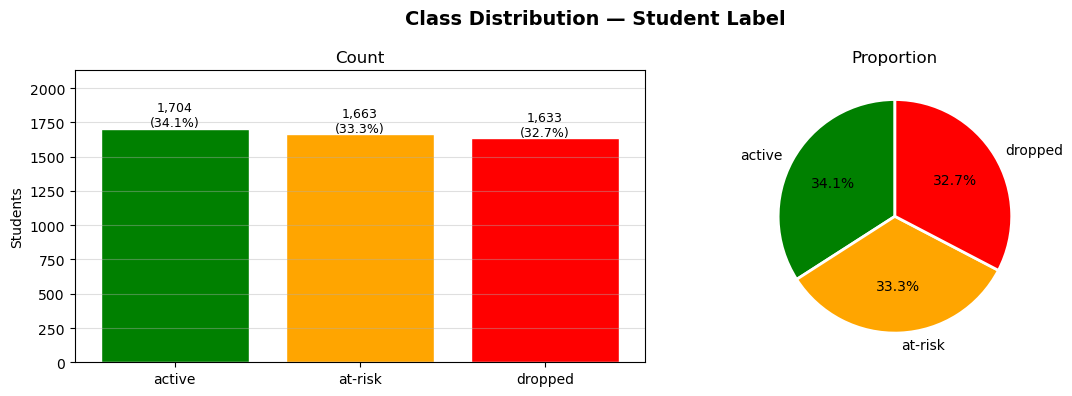

In [4]:
# Label Distribution
vc = data["label_name"].value_counts().reindex(["active", "at-risk", "dropped"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution — Student Label", fontsize=14, fontweight="bold")

bars = axes[0].bar(vc.index, vc.values, color=COLORS, edgecolor="white")
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"{val:,}\n({val/len(data)*100:.1f}%)", ha="center", fontsize=9)
axes[0].set_title("Count"); axes[0].set_ylabel("Students")
axes[0].grid(axis="y", alpha=0.4)
axes[0].set_ylim(0, vc.max() * 1.25)

axes[1].pie(vc.values, labels=vc.index, autopct="%1.1f%%", startangle=90,
            colors=COLORS, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proportion")

plt.tight_layout()
plt.show()

## Age Distribution by Label

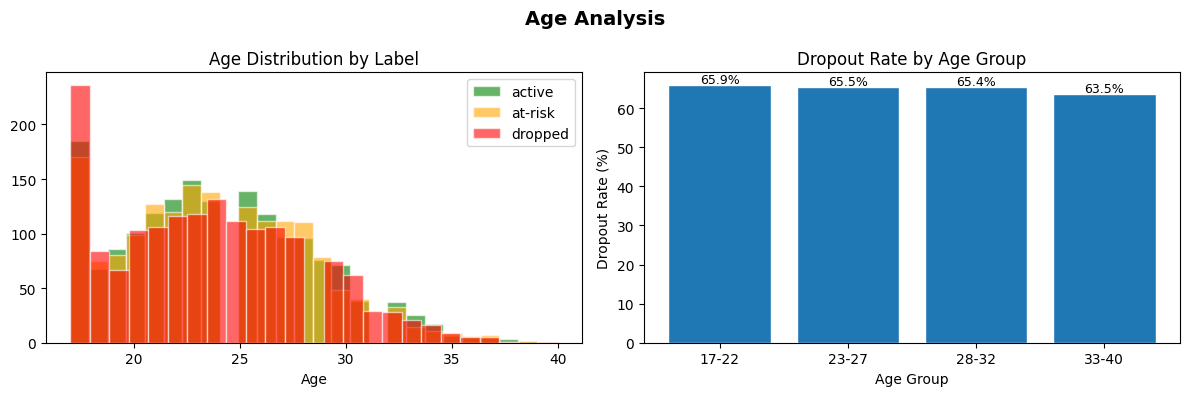

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Age Analysis", fontsize=14, fontweight="bold")

for label, color in PALETTE.items():
    axes[0].hist(data[data["label_name"] == label]["age"], bins=25, alpha=0.6,
                 label=label, color=color, edgecolor="white")
axes[0].set_title("Age Distribution by Label")
axes[0].set_xlabel("Age"); axes[0].legend()

age_bins = pd.cut(data["age"], bins=[17, 22, 27, 32, 40, 50],
                  labels=["17-22", "23-27", "28-32", "33-40", "41-50"])
rate = data.groupby(age_bins, observed=True)["label"].mean() * 100
axes[1].bar(rate.index, rate.values, edgecolor="white")
axes[1].set_title("Dropout Rate by Age Group")
axes[1].set_xlabel("Age Group"); axes[1].set_ylabel("Dropout Rate (%)")
for i, v in enumerate(rate.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Login Frequency & Completion Rate

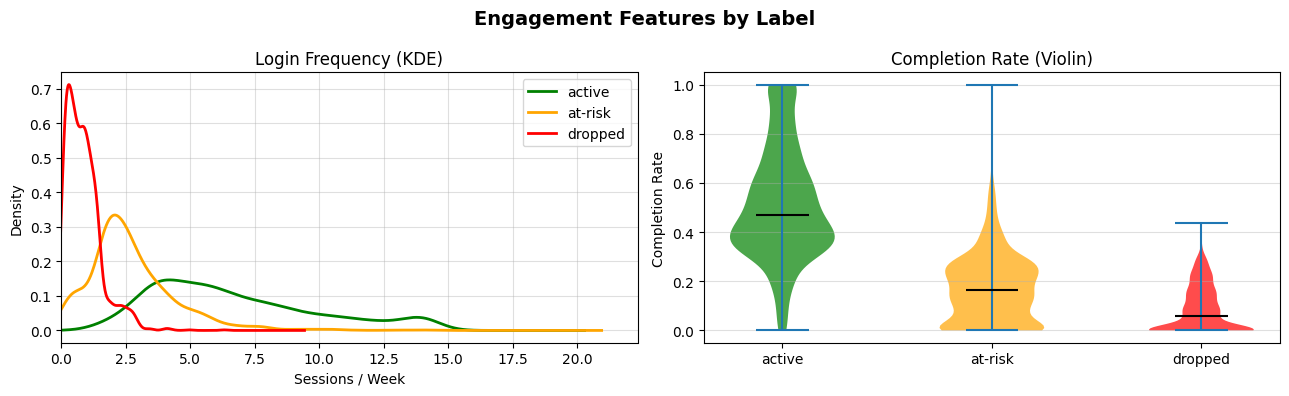

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Engagement Features by Label", fontsize=14, fontweight="bold")

# Login KDE
for label, color in PALETTE.items():
    data[data["label_name"] == label]["login_frequency"].plot.kde(
        ax=axes[0], label=label, color=color, linewidth=2)
axes[0].set_title("Login Frequency (KDE)")
axes[0].set_xlabel("Sessions / Week"); axes[0].set_xlim(left=0)
axes[0].legend(); axes[0].grid(alpha=0.4)

# Completion violin
data_v = [data[data["label_name"] == lbl]["completion_rate"].values
          for lbl in ["active", "at-risk", "dropped"]]
parts = axes[1].violinplot(data_v, showmedians=True)
for pc, color in zip(parts["bodies"], COLORS):
    pc.set_facecolor(color); pc.set_alpha(0.7)
parts["cmedians"].set_color("black")
axes[1].set_xticks([1, 2, 3]); axes[1].set_xticklabels(["active", "at-risk", "dropped"])
axes[1].set_title("Completion Rate (Violin)")
axes[1].set_ylabel("Completion Rate"); axes[1].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

## Dropout % by Region

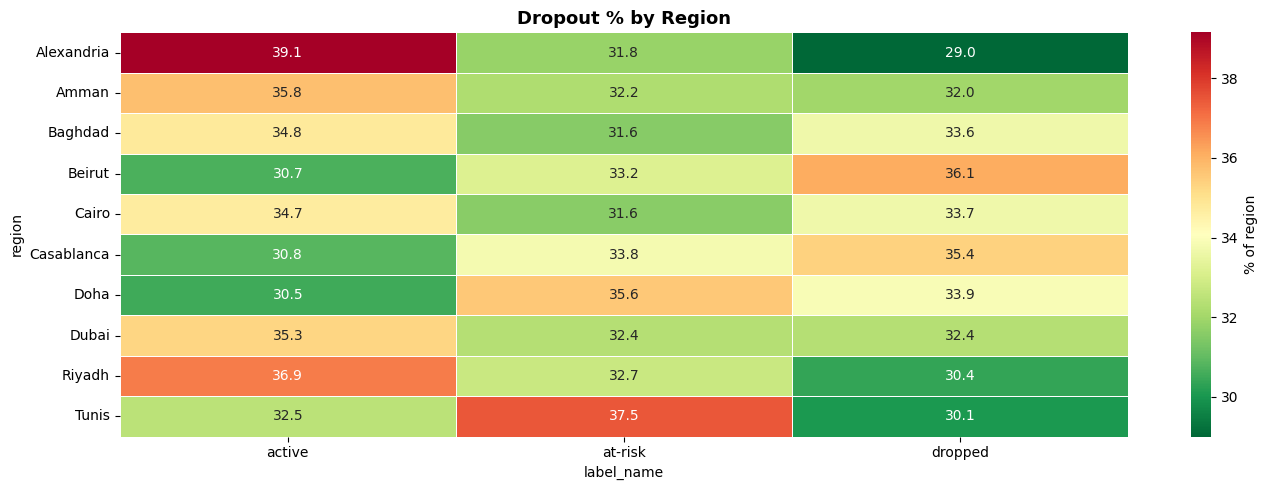

In [15]:
region_label = (data.groupby(["region", "label_name"]).size().unstack(fill_value=0)
                  .reindex(columns=["active", "at-risk", "dropped"]))
region_pct = region_label.div(region_label.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(region_pct, ax=ax, cmap="RdYlGn_r", annot=True, fmt=".1f",
            linewidths=0.5, cbar_kws={"label": "% of region"})
ax.set_title("Dropout % by Region", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Correlation Heatmap

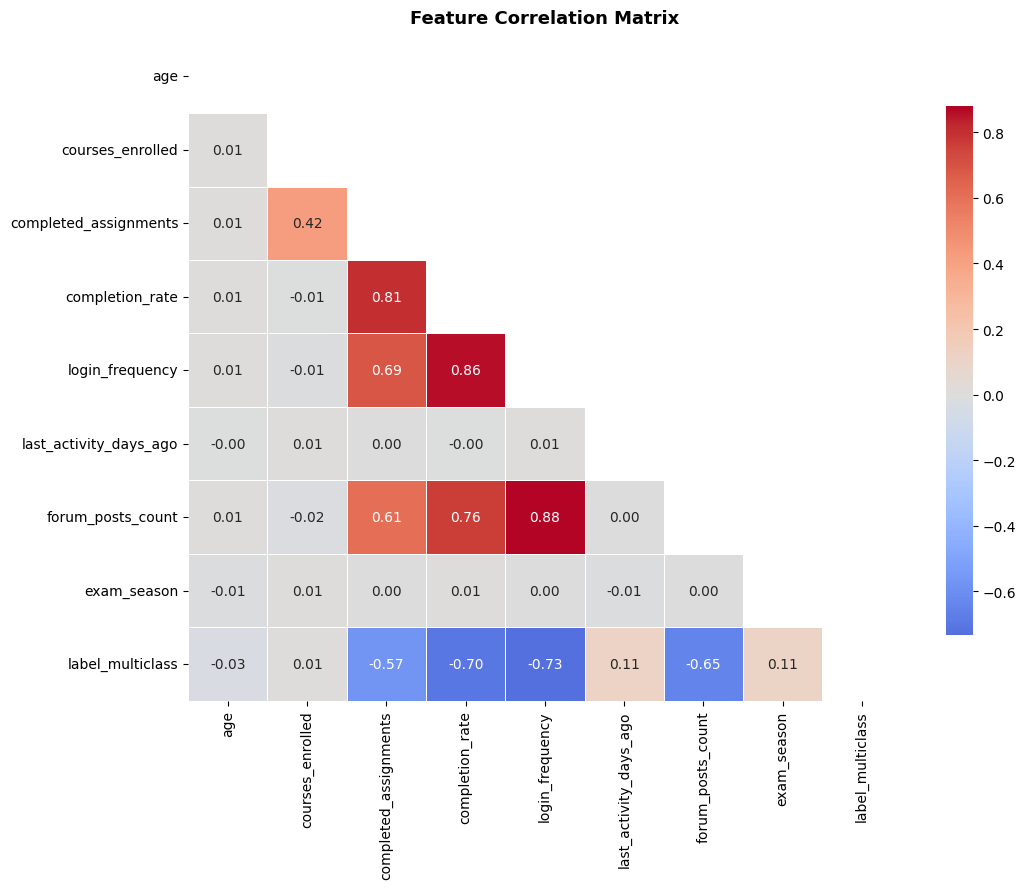


Top correlations with label_multiclass:
login_frequency          -0.732079
completion_rate          -0.704463
forum_posts_count        -0.645485
completed_assignments    -0.573028
last_activity_days_ago    0.113803
exam_season               0.106283
age                      -0.028996
courses_enrolled          0.006983


In [17]:
num_cols = ["age", "courses_enrolled", "completed_assignments", "completion_rate", "login_frequency",
            "last_activity_days_ago", "forum_posts_count", "exam_season", "label_multiclass"]

corr = data[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

print("\nTop correlations with label_multiclass:")
label_corr = corr["label_multiclass"].drop("label_multiclass").sort_values(key=abs, ascending=False)
print(label_corr.to_string())

# Feature Engineering

In [18]:
data["engagement_score"] = (data["login_frequency"] * 0.4 + data["completion_rate"] * 10 * 0.4 + data["forum_posts_count"] * 0.2)
data["inactivity_risk"]  = (data["last_activity_days_ago"] / data["login_frequency"].replace(0, 0.01)).clip(upper=200)
data["assignment_gap"]   = data["courses_enrolled"] * 5 - data["completed_assignments"]
data["active_learner"]   = ((data["login_frequency"] >= 3) & (data["completion_rate"] >= 0.5)).astype(int)
data["high_risk_combo"]  = ((data["login_frequency"] < 1.5) & (data["completion_rate"] < 0.3)).astype(int)

print("New features created:")
for f in ["engagement_score", "inactivity_risk", "assignment_gap", "active_learner", "high_risk_combo"]:
    print(f"- {f}")

data[["engagement_score", "inactivity_risk", "assignment_gap", "active_learner", "high_risk_combo"]].head()

New features created:
- engagement_score
- inactivity_risk
- assignment_gap
- active_learner
- high_risk_combo


,engagement_score,inactivity_risk,assignment_gap,active_learner,high_risk_combo
0,4.5444,1.890359,10,0,0
1,0.3360,8.333333,30,0,1
2,0.8900,20.111732,14,0,0
3,2.0704,11.538462,17,0,0
4,1.1992,11.956522,20,0,1


# Prepare Features & Split Data

In [19]:
FEATURE_COLS = [
    "age", "courses_enrolled", "completed_assignments", "completion_rate",
    "login_frequency", "last_activity_days_ago", "forum_posts_count",
    "exam_season",
    # engineered
    "engagement_score", "inactivity_risk", "assignment_gap",
    "active_learner", "high_risk_combo",
]

le_region = LabelEncoder()
data["region_enc"] = le_region.fit_transform(data["region"])
FEATURE_COLS.append("region_enc")

X        = data[FEATURE_COLS]
y_binary = data["label"]            # 0=active/at-risk  1=dropped
y_multi  = data["label_multiclass"] # 0=active 1=at-risk 2=dropped

X_train, X_test, yb_train, yb_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

print(f"Train : {len(X_train):,}   Test : {len(X_test):,}")
print(f"Features : {len(FEATURE_COLS)}")

Train : 4,000   Test : 1,000
Features : 14


# Binary Classification - Model Comparison

In [20]:
models_binary = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree":  DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest":  RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boost": GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42),
    "Extra Trees":    ExtraTreesClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models_binary.items():
    cv_scores = cross_val_score(model, X_train, yb_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    model.fit(X_train, yb_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(yb_test, y_proba)
    f1  = f1_score(yb_test, y_pred, average="weighted")
    results[name] = {"cv_auc": cv_scores.mean(), "cv_std": cv_scores.std(), "test_auc": auc, "f1": f1,
                     "model": model, "y_pred": y_pred, "y_proba": y_proba}
    print(f"{name:22s}  CV-AUC={cv_scores.mean():.4f}±{cv_scores.std():.4f}"
          f"Test-AUC={auc:.4f}  F1={f1:.4f}")

best_name = max(results, key=lambda k: results[k]["test_auc"])
best      = results[best_name]
print(f"\nBest model : {best_name}  (AUC={best['test_auc']:.4f})")

Logistic Regression     CV-AUC=0.9662±0.0090Test-AUC=0.9703  F1=0.9156
Decision Tree           CV-AUC=0.9491±0.0102Test-AUC=0.9584  F1=0.9276
Random Forest           CV-AUC=0.9790±0.0053Test-AUC=0.9820  F1=0.9267
Gradient Boost          CV-AUC=0.9800±0.0053Test-AUC=0.9830  F1=0.9300
Extra Trees             CV-AUC=0.9728±0.0076Test-AUC=0.9770  F1=0.9224

Best model : Gradient Boost  (AUC=0.9830)


## Model Comparison Bar Chart

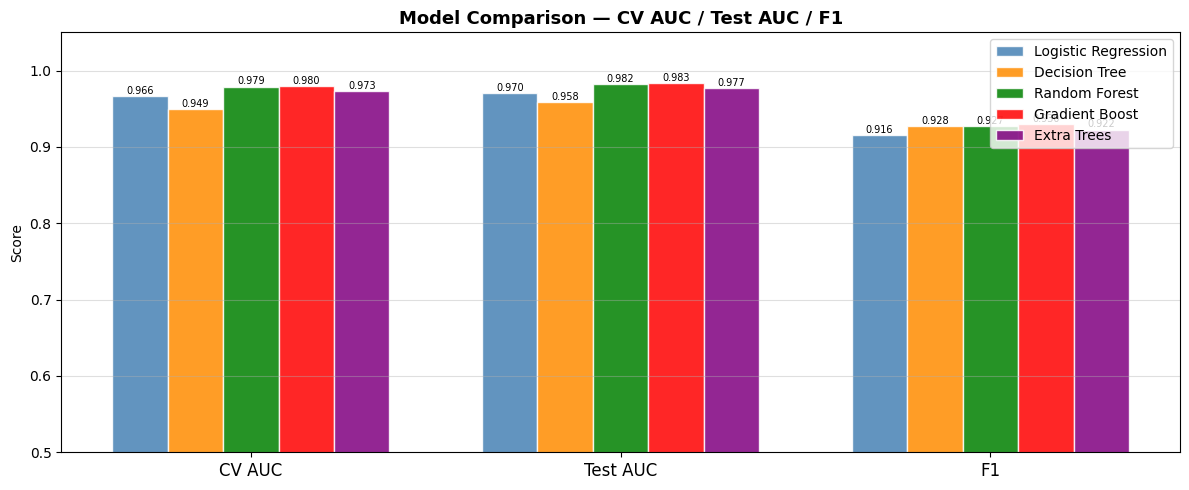

In [21]:
metrics = ["cv_auc", "test_auc", "f1"]
metric_lbls = ["CV AUC", "Test AUC", "F1"]
x = np.arange(len(metrics))
width = 0.15
model_names = list(results.keys())
ROC_COLORS = ["steelblue", "darkorange", "green", "red", "purple"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, mname in enumerate(model_names):
    vals = [results[mname][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=mname, color=ROC_COLORS[i], edgecolor="white", alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f"{v:.3f}", ha="center", fontsize=7)

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_lbls, fontsize=12)
ax.set_ylim(0.5, 1.05)
ax.set_title("Model Comparison — CV AUC / Test AUC / F1", fontsize=13, fontweight="bold")
ax.legend(loc="upper right"); ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

## ROC Curves - All Models

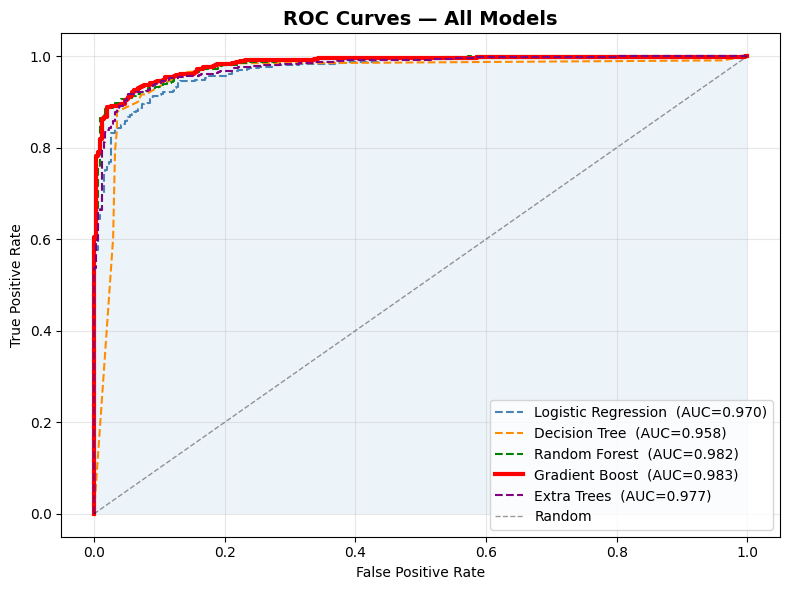

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(yb_test, res["y_proba"])
    lw = 3 if name == best_name else 1.5
    ax.plot(fpr, tpr, linewidth=lw, color=ROC_COLORS[i], linestyle="-" if name == best_name else "--", label=f"{name}  (AUC={res['test_auc']:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.4, label="Random")
ax.fill_between(*roc_curve(yb_test, best["y_proba"])[:2], alpha=0.08)
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5-Fold CV AUC with Error Bars

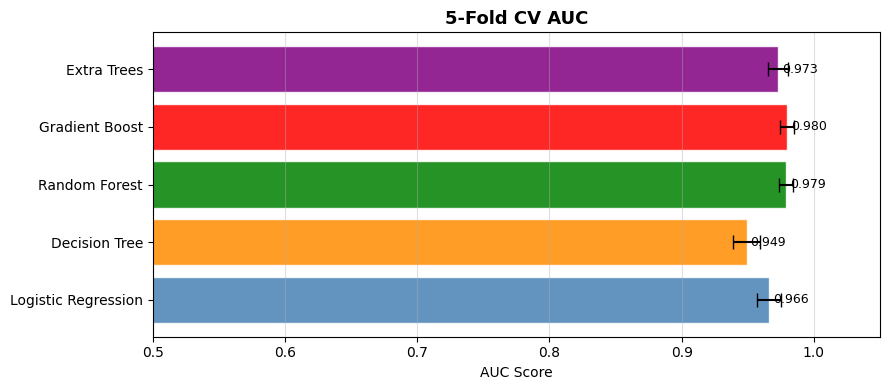

In [23]:
names  = list(results.keys())
cv_auc = [results[n]["cv_auc"] for n in names]
cv_std = [results[n]["cv_std"] for n in names]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(names, cv_auc, xerr=cv_std, color=ROC_COLORS[:len(names)], edgecolor="white", capsize=5, alpha=0.85)
for bar, val in zip(bars, cv_auc):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)
ax.set_title("5-Fold CV AUC", fontsize=13, fontweight="bold")
ax.set_xlabel("AUC Score"); ax.set_xlim(0.5, 1.05)
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

## Confusion Matrix - Best Model

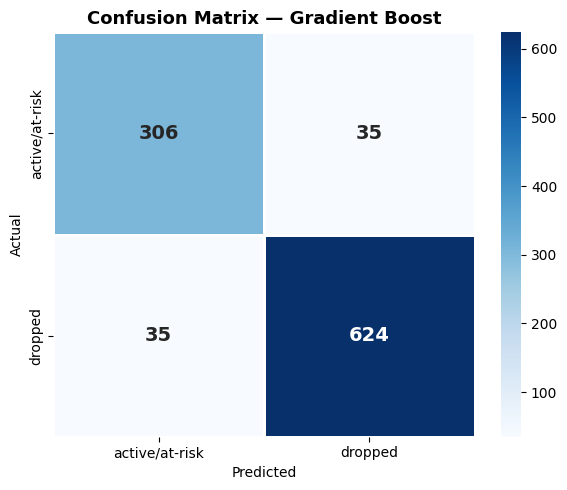


Classification Report — Gradient Boost:
                precision    recall  f1-score   support

active/at-risk       0.90      0.90      0.90       341
       dropped       0.95      0.95      0.95       659

      accuracy                           0.93      1000
     macro avg       0.92      0.92      0.92      1000
  weighted avg       0.93      0.93      0.93      1000



In [24]:
cm = confusion_matrix(yb_test, best["y_pred"])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=["active/at-risk", "dropped"],
            yticklabels=["active/at-risk", "dropped"], linewidths=1, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13, fontweight="bold")
ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

print(f"\nClassification Report — {best_name}:")
print(classification_report(yb_test, best["y_pred"],
                             target_names=["active/at-risk", "dropped"]))

## Feature Importance

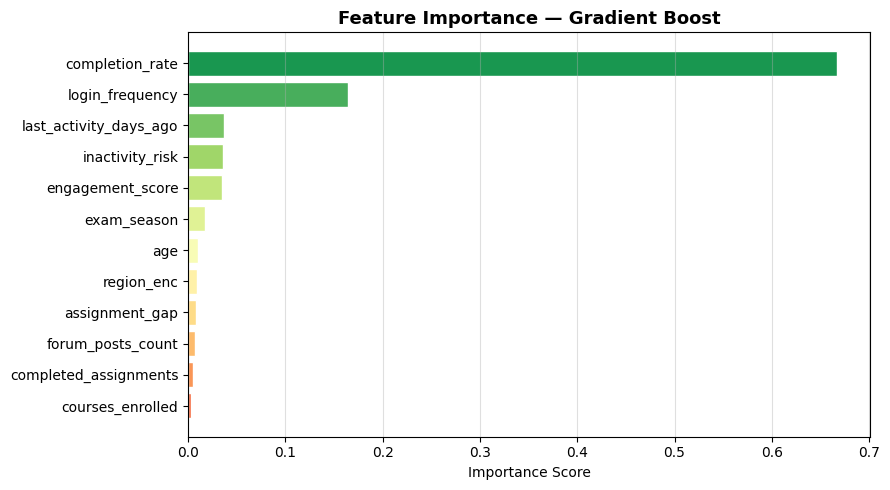

In [25]:
best_model = best["model"]
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "named_steps"):
    importances = np.abs(best_model.named_steps["clf"].coef_[0])
else:
    importances = np.ones(len(FEATURE_COLS))

feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)
top_feat  = feat_imp.tail(12)

fig, ax = plt.subplots(figsize=(9, 5))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top_feat)))
ax.barh(top_feat.index, top_feat.values, color=colors_fi, edgecolor="white")
ax.set_title(f"Feature Importance — {best_name}", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score"); ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

# Multi-Class Metrics

## Multi-Class Classification (active / at-risk / dropped)

In [26]:
et_multi = ExtraTreesClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
et_multi.fit(Xm_train, ym_train)
ym_pred  = et_multi.predict(Xm_test)
ym_proba = et_multi.predict_proba(Xm_test)

auc_multi = roc_auc_score(ym_test, ym_proba, multi_class="ovr", average="macro")
print(f"Macro AUC (OvR) : {auc_multi:.4f}\n")
print(classification_report(ym_test, ym_pred, target_names=["active", "at-risk", "dropped"]))

Macro AUC (OvR) : 0.9459

              precision    recall  f1-score   support

      active       0.87      0.87      0.87       341
     at-risk       0.74      0.74      0.74       333
     dropped       0.87      0.88      0.88       326

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



## Multi-Class Confusion Matrix

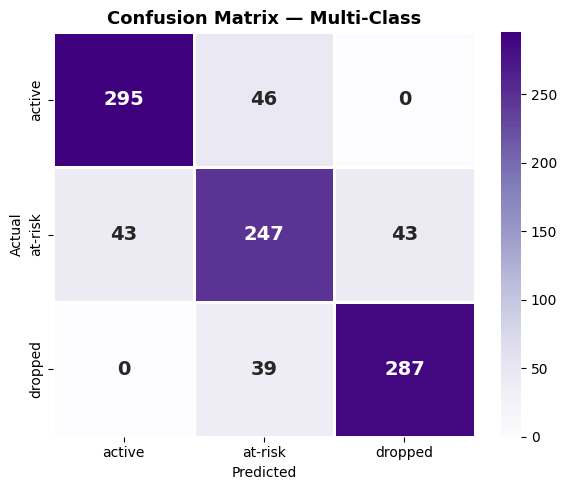

In [27]:
cm_m = confusion_matrix(ym_test, ym_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_m, annot=True, fmt="d", cmap="Purples", ax=ax,
            xticklabels=["active", "at-risk", "dropped"], yticklabels=["active", "at-risk", "dropped"],
            linewidths=1, linecolor="white", annot_kws={"size": 14, "weight": "bold"})
ax.set_title("Confusion Matrix — Multi-Class", fontsize=13, fontweight="bold")
ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

# Risk Score Analysis

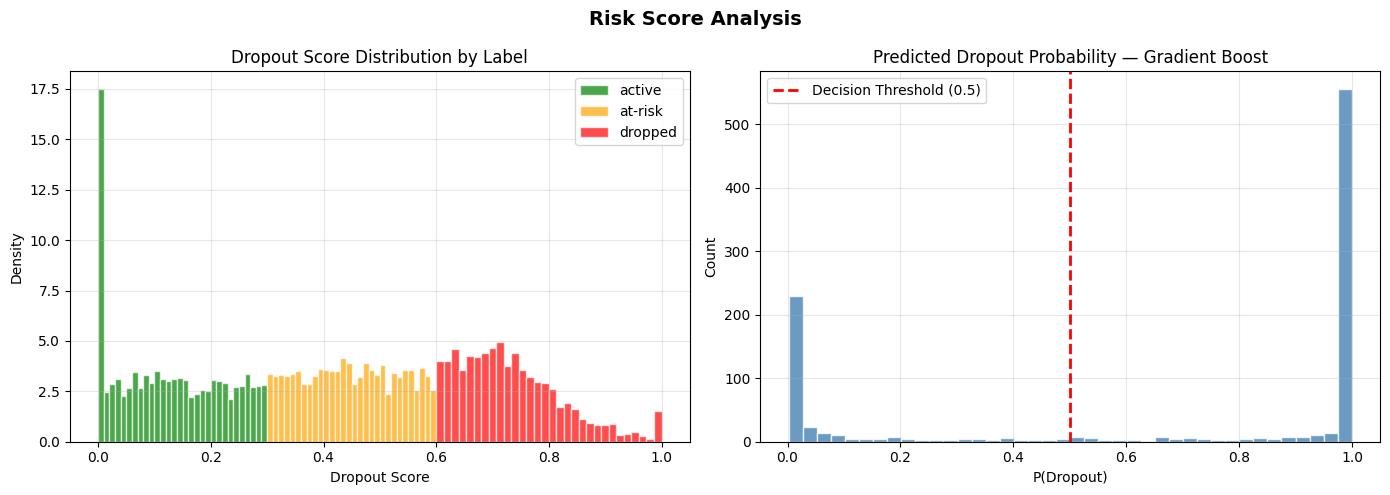

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Risk Score Analysis", fontsize=14, fontweight="bold")

# Dropout score distribution by label
for label, color in PALETTE.items():
    subset = data[data["label_name"] == label]["dropout_score"]
    axes[0].hist(subset, bins=30, alpha=0.7, label=label, color=color,
                 density=True, edgecolor="white")
axes[0].set_title("Dropout Score Distribution by Label")
axes[0].set_xlabel("Dropout Score"); axes[0].set_ylabel("Density")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Predicted probability (best binary model)
axes[1].hist(best["y_proba"], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(0.5, color="red", linewidth=2, linestyle="--", label="Decision Threshold (0.5)")
axes[1].set_title(f"Predicted Dropout Probability — {best_name}")
axes[1].set_xlabel("P(Dropout)"); axes[1].set_ylabel("Count")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Final Summary

In [29]:
summary = pd.DataFrame([
    {"Model": n,
     "CV_AUC": f"{v['cv_auc']:.4f}±{v['cv_std']:.4f}",
     "Test_AUC": f"{v['test_auc']:.4f}",
     "F1": f"{v['f1']:.4f}",
     "Best": "Winner" if n == best_name else ""}
    for n, v in results.items()
])

print("Binary Classification Results:")
print(summary.to_string(index=False))
print(f"\nMulti-Class Extra Trees → Macro AUC (OvR) = {auc_multi:.4f}")

Binary Classification Results:
              Model        CV_AUC Test_AUC     F1   Best
Logistic Regression 0.9662±0.0090   0.9703 0.9156       
      Decision Tree 0.9491±0.0102   0.9584 0.9276       
      Random Forest 0.9790±0.0053   0.9820 0.9267       
     Gradient Boost 0.9800±0.0053   0.9830 0.9300 Winner
        Extra Trees 0.9728±0.0076   0.9770 0.9224       

Multi-Class Extra Trees → Macro AUC (OvR) = 0.9459
